<a href="https://colab.research.google.com/github/SoumyadeepChattopadhyay2004/Urban-Heat-Green-Cover-Impact-Modeling/blob/main/Urban_Heat_Green_Cover_Impact_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urban Heat & Green-Cover Impact Modeling

## Research objective

**Primary question:**  
> How is urban vegetation (measured by NDVI) associated with urban land-surface-temperature anomaly after accounting for impervious surface, population density, climate zone, and year?

### Important scope correction

The supplied dataset contains **LST anomaly (`lst_anomaly_c`)**, not raw Land Surface Temperature (LST). Therefore, the dependent variable in this notebook is explicitly:

**LST anomaly (°C)**

Also, the supplied dataset does **not** contain elevation, distance to water bodies, latitude/longitude, or a separate built-up-area variable. Those variables must not be claimed as controls until they are actually added to the dataset.

The analysis is observational. Regression coefficients should be described as **adjusted associations**, not causal effects or proof that vegetation "causes" a temperature change.

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

## Load the Dataset

In [4]:
try:
  df = pd.read_csv("/content/global_urban_heat_island_2015_2025.csv")
  print(f"Successfully loaded")
except:
  print(f"Failed to load")

Successfully loaded


In [5]:
print(f"Shape: {df.shape}")
print(f"Cities: {df['city'].nunique()}")
print(f"Years: {df['year'].min()}–{df['year'].max()}")

Shape: (550, 10)
Cities: 50
Years: 2015–2025


In [6]:
df.head()

,city,country,year,lst_anomaly_c,ndvi_mean,impervious_pct,tree_canopy_pct,pop_density_km2,heat_mortality_per_100k,climate_zone
0,Tokyo,Japan,2015,3.815,0.2018,78,16,6168,1.8,Cfa
1,Tokyo,Japan,2016,4.244,0.2048,78,16,6168,1.8,Cfa
2,Tokyo,Japan,2017,3.793,0.2060,78,16,6168,1.8,Cfa
3,Tokyo,Japan,2018,3.618,0.2134,78,16,6168,1.8,Cfa
4,Tokyo,Japan,2019,3.958,0.2050,78,16,6168,1.8,Cfa


In [7]:
df.describe()

,year,lst_anomaly_c,ndvi_mean,impervious_pct,tree_canopy_pct,pop_density_km2,heat_mortality_per_100k
count,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,517.000000
mean,2020.000000,3.021175,0.179200,66.480000,14.840000,9484.880000,2.393617
std,3.165156,0.472222,0.064198,7.797445,7.818282,11864.495547,1.300424
min,2015.000000,1.825000,0.027900,45.000000,2.000000,1254.000000,0.400000
25%,2017.000000,2.701500,0.137575,61.000000,8.000000,3229.000000,1.400000
50%,2020.000000,3.019000,0.182200,67.500000,14.000000,5927.500000,2.100000
75%,2023.000000,3.338750,0.221675,72.000000,21.000000,10431.000000,3.000000
max,2025.000000,4.244000,0.316200,82.000000,33.000000,71263.000000,6.200000


## Data dictionary and structural checks

Expected variables:

- `lst_anomaly_c` — response variable; LST anomaly in °C
- `ndvi_mean` — vegetation index
- `impervious_pct` — impervious surface percentage; use this as an urban surface-density proxy, not as an exact "built-up area" measurement
- `tree_canopy_pct` — vegetation-related sensitivity variable
- `pop_density_km2` — population density
- `climate_zone` — climate classification
- `city`, `country`, `year` — panel identifiers
- `heat_mortality_per_100k` — health outcome; **not used in the temperature model**

In [8]:
print(f"Columns:")
print(df.columns.tolist())

print(f"\nData types:")
display(df.dtypes.to_frame("dtype"))

print(f"\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("f\nDuplicate rows:", df.duplicated().sum())

Columns:
['city', 'country', 'year', 'lst_anomaly_c', 'ndvi_mean', 'impervious_pct', 'tree_canopy_pct', 'pop_density_km2', 'heat_mortality_per_100k', 'climate_zone']

Data types:


,dtype
city,object
country,object
year,int64
lst_anomaly_c,float64
ndvi_mean,float64
impervious_pct,int64
tree_canopy_pct,int64
pop_density_km2,int64
heat_mortality_per_100k,float64
climate_zone,object



Missing values:


,missing
heat_mortality_per_100k,33
city,0
country,0
year,0
ndvi_mean,0
lst_anomaly_c,0
impervious_pct,0
tree_canopy_pct,0
pop_density_km2,0
climate_zone,0


f
Duplicate rows: 0


In [9]:
# Panel structure
panel_check = df.groupby("city").agg(
    n_years=("year", "nunique"),
    first_year=("year", "min"),
    last_year=("year", "max")
)
display(panel_check.head())

assert df["city"].nunique() == 50, "Unexpected number of cities; inspect the dataset."
assert df["year"].min() == 2015 and df["year"].max() == 2025, "Unexpected year range."

,n_years,first_year,last_year
city,,,
Ahmedabad,11,2015,2025
Bangalore,11,2015,2025
Bangkok,11,2015,2025
Beijing,11,2015,2025
Bogotá,11,2015,2025


## Descriptive statistics

First establish the empirical range before fitting any model. This is also where impossible values should be detected.

For the current data, the core variables are complete. The 33 missing observations in the heat-mortality variable do not affect the core analysis because that variable is excluded from the temperature model.

In [10]:
core_cols = [
    "lst_anomaly_c",
    "ndvi_mean",
    "impervious_pct",
    "tree_canopy_pct",
    "pop_density_km2",
]

display(df[core_cols].describe().T)

# Plausibility checks
assert df["ndvi_mean"].between(-1, 1).all(), "NDVI outside expected [-1, 1] range."
assert df["impervious_pct"].between(0, 100).all(), "Impervious percentage outside [0, 100]."
assert df["tree_canopy_pct"].between(0, 100).all(), "Tree canopy percentage outside [0, 100]."
assert (df["pop_density_km2"] >= 0).all(), "Negative population density detected."

,count,mean,std,min,25%,50%,75%,max
lst_anomaly_c,550.0,3.021175,0.472222,1.8250,2.701500,3.0190,3.338750,4.2440
ndvi_mean,550.0,0.179200,0.064198,0.0279,0.137575,0.1822,0.221675,0.3162
impervious_pct,550.0,66.480000,7.797445,45.0000,61.000000,67.5000,72.000000,82.0000
tree_canopy_pct,550.0,14.840000,7.818282,2.0000,8.000000,14.0000,21.000000,33.0000
pop_density_km2,550.0,9484.880000,11864.495547,1254.0000,3229.000000,5927.5000,10431.000000,71263.0000


## Exploratory analysis

The first research relationship is NDVI versus LST anomaly. The scatterplot is descriptive only; it is not evidence of causality.

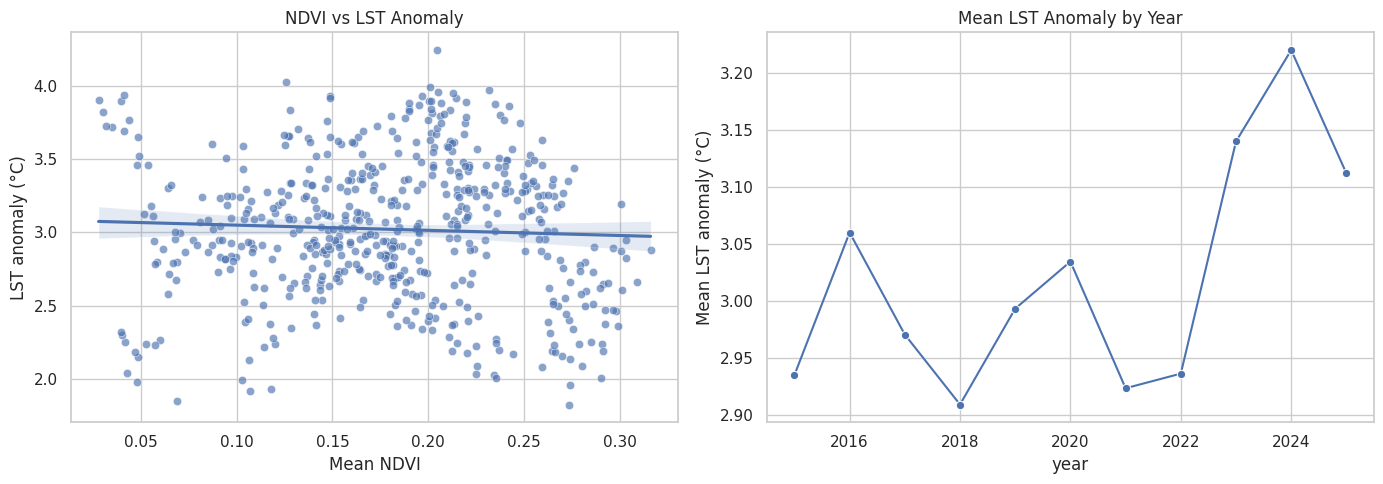

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df, x="ndvi_mean", y="lst_anomaly_c",
    alpha=0.65, ax=axes[0]
)
sns.regplot(
    data=df, x="ndvi_mean", y="lst_anomaly_c",
    scatter=False, ci=95, ax=axes[0]
)
axes[0].set_title("NDVI vs LST Anomaly")
axes[0].set_xlabel("Mean NDVI")
axes[0].set_ylabel("LST anomaly (°C)")

year_mean = df.groupby("year", as_index=False)["lst_anomaly_c"].mean()
sns.lineplot(data=year_mean, x="year", y="lst_anomaly_c", marker="o", ax=axes[1])
axes[1].set_title("Mean LST Anomaly by Year")
axes[1].set_ylabel("Mean LST anomaly (°C)")

plt.tight_layout()
plt.show()

## Correlation and multicollinearity

A major issue in the original notebook is that NDVI and tree-canopy percentage are very strongly correlated. Including both in the same regression can make their individual coefficients unstable.

Therefore:

- **Primary vegetation model:** NDVI is the vegetation exposure.
- **Sensitivity model:** tree canopy is examined separately.
- A model containing both is retained only as a diagnostic/sensitivity analysis.

Correlation is not the same thing as multicollinearity, so VIF is also calculated.

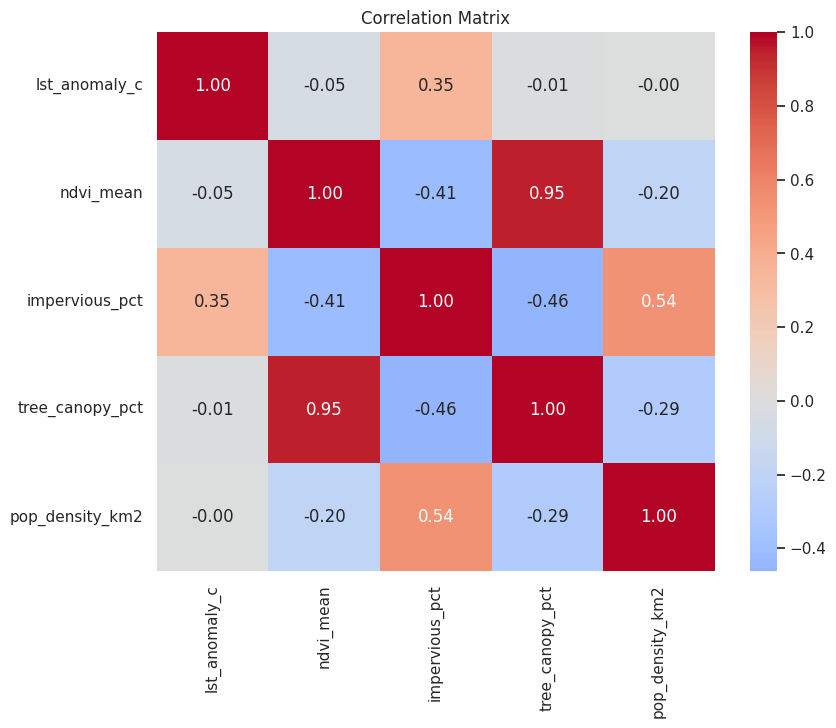

In [12]:
corr_cols = [
    "lst_anomaly_c",
    "ndvi_mean",
    "impervious_pct",
    "tree_canopy_pct",
    "pop_density_km2",
]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [13]:
X_vif = sm.add_constant(df[[
    "ndvi_mean",
    "impervious_pct",
    "tree_canopy_pct",
    "pop_density_km2"
]])

vif = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
display(vif)

,feature,VIF
0,const,1.000000
1,ndvi_mean,10.088339
2,impervious_pct,1.642781
3,tree_canopy_pct,10.679501
4,pop_density_km2,1.482132


## Model 1 — Simple Linear Regression

This answers the narrow question:

> What is the unadjusted linear association between NDVI and LST anomaly?

It should **not** be presented as the final scientific estimate because urban form and climate differ substantially across cities.

In [14]:
slr = smf.ols(
    "lst_anomaly_c ~ ndvi_mean",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["city"]}
)

print(slr.summary())

                            OLS Regression Results                            
Dep. Variable:          lst_anomaly_c   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                    0.1047
Date:                Thu, 24 Sep 2026   Prob (F-statistic):              0.748
Time:                        16:17:25   Log-Likelihood:                -366.61
No. Observations:                 550   AIC:                             737.2
Df Residuals:                     548   BIC:                             745.8
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.0844      0.202     15.266      0.0

## Model 2 — Adjusted Multiple Linear Regression

Primary adjusted specification:

**LST anomaly ~ NDVI + impervious surface + population density + climate zone + year**

Two important corrections are made here:

1. `climate_zone` and `year` are included because they represent major systematic environmental/temporal differences.
2. Standard errors are clustered by city because the dataset is a repeated city-year panel. Treating all 550 observations as independent is inappropriate.

The coefficient on NDVI is therefore interpreted as an **adjusted association**, conditional on the variables included in this specification.

In [15]:
mlr = smf.ols(
    "lst_anomaly_c ~ ndvi_mean + impervious_pct + pop_density_km2 + C(climate_zone) + C(year)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["city"]}
)

print(mlr.summary())

                            OLS Regression Results                            
Dep. Variable:          lst_anomaly_c   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     180.2
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.84e-39
Time:                        16:17:26   Log-Likelihood:                -114.64
No. Observations:                 550   AIC:                             285.3
Df Residuals:                     522   BIC:                             406.0
Df Model:                          27                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 22
  res = self.wald_test(


In [16]:
coef_table = pd.DataFrame({
    "coefficient": mlr.params,
    "std_error_clustered_by_city": mlr.bse,
    "p_value": mlr.pvalues,
    "CI_low": mlr.conf_int()[0],
    "CI_high": mlr.conf_int()[1],
})
display(coef_table.loc[["ndvi_mean", "impervious_pct", "pop_density_km2"]])

,coefficient,std_error_clustered_by_city,p_value,CI_low,CI_high
ndvi_mean,0.012079,0.931750,9.896565e-01,-1.814117,1.838276
impervious_pct,0.027078,0.005016,6.734683e-08,0.017247,0.036910
pop_density_km2,-0.000003,0.000003,1.764701e-01,-0.000008,0.000002


## Academic interpretation of the NDVI coefficient

For a linear model, a 0.1-unit NDVI change corresponds to:

**temperature association = 0.1 × NDVI coefficient**

So,a 0.1 increase in NDVI is associated with an estimated X °C difference in LST anomaly, holding the other variables in the model constant.

In [17]:
beta_ndvi = mlr.params["ndvi_mean"]
p_ndvi = mlr.pvalues["ndvi_mean"]
ci_low, ci_high = mlr.conf_int().loc["ndvi_mean"]

effect_01 = 0.1 * beta_ndvi
effect_01_low = 0.1 * ci_low
effect_01_high = 0.1 * ci_high

print(f"NDVI coefficient: {beta_ndvi:.4f} °C per 1.0 NDVI unit")
print(f"Estimated association for +0.1 NDVI: {effect_01:.3f} °C")
print(f"95% CI for +0.1 NDVI: [{effect_01_low:.3f}, {effect_01_high:.3f}] °C")
print(f"p-value: {p_ndvi:.4f}")

NDVI coefficient: 0.0121 °C per 1.0 NDVI unit
Estimated association for +0.1 NDVI: 0.001 °C
95% CI for +0.1 NDVI: [-0.181, 0.184] °C
p-value: 0.9897


## Tree-canopy sensitivity model

Because NDVI and tree canopy are highly correlated, estimate a separate model rather than interpreting both vegetation coefficients as independent effects.

This asks whether the conclusion is sensitive to using a different vegetation measure.

In [18]:
canopy_model = smf.ols(
    "lst_anomaly_c ~ tree_canopy_pct + impervious_pct + pop_density_km2 + C(climate_zone) + C(year)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["city"]}
)

print(canopy_model.summary())

print("\nTree-canopy coefficient:")
print(canopy_model.params["tree_canopy_pct"])
print("p-value:", canopy_model.pvalues["tree_canopy_pct"])

                            OLS Regression Results                            
Dep. Variable:          lst_anomaly_c   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     304.5
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           5.70e-45
Time:                        16:17:26   Log-Likelihood:                -114.64
No. Observations:                 550   AIC:                             285.3
Df Residuals:                     522   BIC:                             405.9
Df Model:                          27                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 22
  res = self.wald_test(


## Model 3 — Quadratic NDVI relationship

A linear effect assumes the association is constant across the NDVI range. A quadratic term allows curvature.

To reduce numerical collinearity, NDVI is centered before squaring:

**NDVI_centered = NDVI − mean(NDVI)**

The quadratic model is exploratory. Do not automatically prefer it because it has a curve; compare adjusted R²/AIC/BIC and examine whether the curvature is scientifically plausible.

In [19]:
df["ndvi_centered"] = df["ndvi_mean"] - df["ndvi_mean"].mean()

quadratic = smf.ols(
    "lst_anomaly_c ~ ndvi_centered + I(ndvi_centered**2) + impervious_pct + pop_density_km2 + C(climate_zone) + C(year)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["city"]}
)

print(quadratic.summary())

                            OLS Regression Results                            
Dep. Variable:          lst_anomaly_c   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     232.6
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           2.40e-42
Time:                        16:17:27   Log-Likelihood:                -106.19
No. Observations:                 550   AIC:                             270.4
Df Residuals:                     521   BIC:                             395.4
Df Model:                          28                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 23
  res = self.wald_test(


In [20]:
model_comparison = pd.DataFrame({
    "Model": ["SLR", "Adjusted MLR", "Quadratic NDVI"],
    "R2": [slr.rsquared, mlr.rsquared, quadratic.rsquared],
    "Adjusted_R2": [slr.rsquared_adj, mlr.rsquared_adj, quadratic.rsquared_adj],
    "AIC": [slr.aic, mlr.aic, quadratic.aic],
    "BIC": [slr.bic, mlr.bic, quadratic.bic],
})
display(model_comparison)

,Model,R2,Adjusted_R2,AIC,BIC
0,SLR,0.002301,0.000480,737.226939,745.846776
1,Adjusted MLR,0.600916,0.580274,285.273311,405.951023
2,Quadratic NDVI,0.612992,0.592193,270.373233,395.360863


## Visualize the fitted quadratic relationship

This plot is descriptive. It should be interpreted over the observed NDVI range rather than extrapolated beyond it.

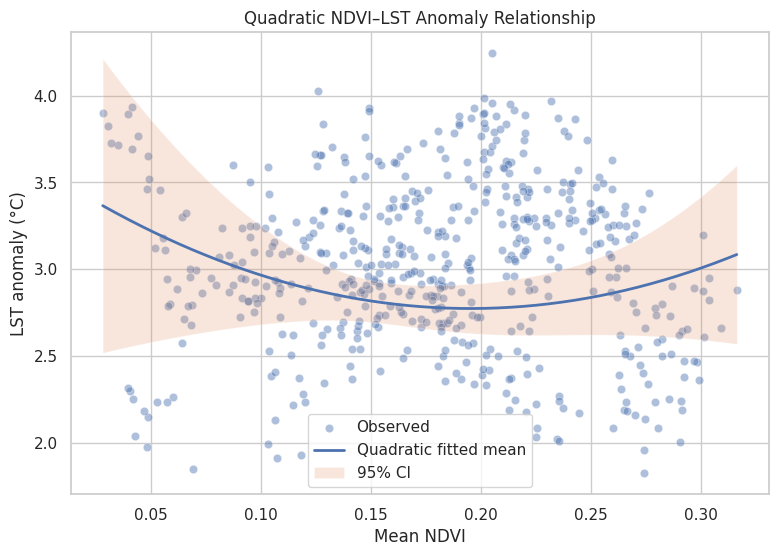

In [21]:
ndvi_grid = np.linspace(df["ndvi_mean"].min(), df["ndvi_mean"].max(), 200)

pred_df = pd.DataFrame({
    "ndvi_mean": ndvi_grid,
    "ndvi_centered": ndvi_grid - df["ndvi_mean"].mean(),
    "impervious_pct": df["impervious_pct"].median(),
    "pop_density_km2": df["pop_density_km2"].median(),
    "climate_zone": df["climate_zone"].mode()[0],
    "year": df["year"].median(),
})

pred = quadratic.get_prediction(pred_df).summary_frame(alpha=0.05)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x="ndvi_mean", y="lst_anomaly_c",
    alpha=0.45, label="Observed"
)
plt.plot(ndvi_grid, pred["mean"], linewidth=2, label="Quadratic fitted mean")
plt.fill_between(
    ndvi_grid, pred["mean_ci_lower"], pred["mean_ci_upper"],
    alpha=0.2, label="95% CI"
)
plt.xlabel("Mean NDVI")
plt.ylabel("LST anomaly (°C)")
plt.title("Quadratic NDVI–LST Anomaly Relationship")
plt.legend()
plt.show()

## Residual diagnostics

Residual analysis is essential for an academic regression study.

We inspect:

- residuals vs fitted values
- Q-Q plot
- heteroskedasticity
- within-city temporal dependence
- residual distributions by city

The original model reported a Durbin–Watson statistic around 0.45, which is a warning sign for serial dependence in this repeated city-year data. Clustered standard errors help with within-city dependence in inference, but they do not make the observations independent.

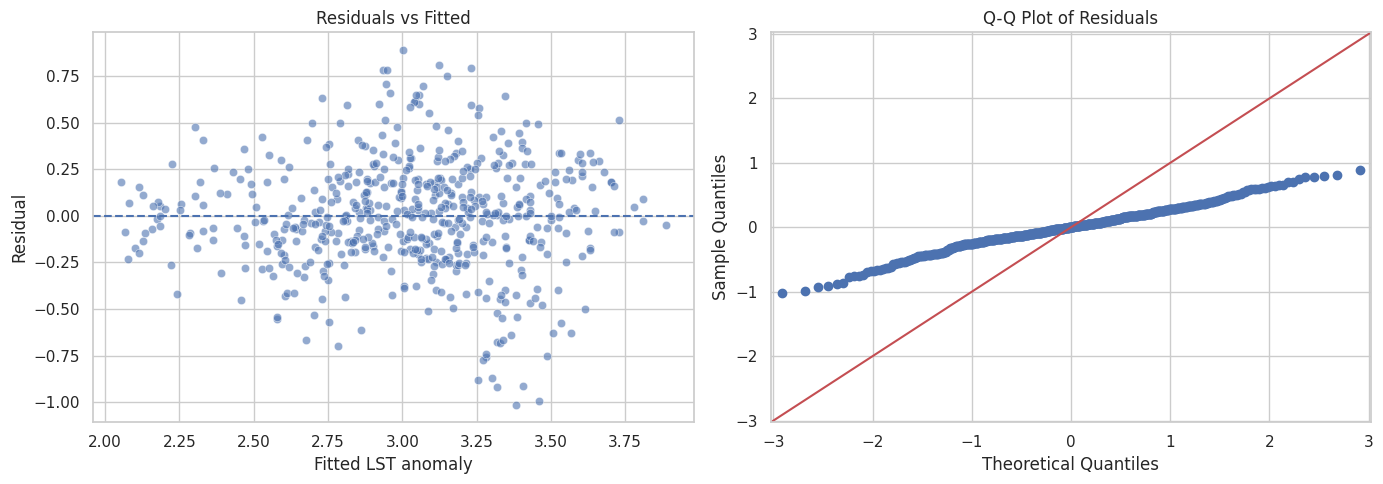

In [22]:
df["fitted_mlr"] = mlr.fittedvalues
df["residual_mlr"] = mlr.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=df["fitted_mlr"], y=df["residual_mlr"],
    alpha=0.6, ax=axes[0]
)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Fitted LST anomaly")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(df["residual_mlr"], line="45", ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [23]:
bp = het_breuschpagan(df["residual_mlr"], mlr.model.exog)
bp_names = ["LM statistic", "LM p-value", "F statistic", "F p-value"]
print("Breusch–Pagan test:")
display(pd.Series(bp, index=bp_names))

print("Naive Durbin–Watson diagnostic:", durbin_watson(df["residual_mlr"]))

Breusch–Pagan test:


,0
LM statistic,1.119952e+02
LM p-value,2.549964e-12
F statistic,4.943417e+00
F p-value,5.657831e-14


Naive Durbin–Watson diagnostic: 0.5928497629021033


## Residual patterns by city and climate zone

The supplied dataset has no latitude/longitude columns, so a genuine spatial residual map or Moran's I analysis cannot be performed yet.

We therefore perform the strongest valid residual analysis available from the current data: residual summaries by city and climate zone.

In [24]:
city_residuals = (
    df.groupby("city")
      .agg(
          mean_residual=("residual_mlr", "mean"),
          sd_residual=("residual_mlr", "std"),
          mean_abs_residual=("residual_mlr", lambda x: np.mean(np.abs(x))),
          n=("residual_mlr", "size")
      )
      .sort_values("mean_abs_residual", ascending=False)
)

display(city_residuals.head(15))

,mean_residual,sd_residual,mean_abs_residual,n
city,,,,
Buenos Aires,-0.822168,0.128952,0.822168,11
Riyadh,0.702904,0.117413,0.702904,11
São Paulo,-0.584609,0.135303,0.584609,11
Delhi,0.518235,0.152198,0.518235,11
Bogotá,-0.510262,0.135248,0.510262,11
Kolkata,0.425164,0.202357,0.425164,11
Cairo,-0.392506,0.124038,0.392506,11
Nagoya,0.386955,0.134982,0.386955,11
Karachi,-0.310398,0.150779,0.310982,11


In [25]:
climate_residuals = (
    df.groupby("climate_zone")
      .agg(
          mean_residual=("residual_mlr", "mean"),
          mean_abs_residual=("residual_mlr", lambda x: np.mean(np.abs(x))),
          n=("residual_mlr", "size")
      )
      .sort_values("mean_abs_residual", ascending=False)
)

display(climate_residuals)

,mean_residual,mean_abs_residual,n
climate_zone,,,
BWh,4.951729e-13,0.468797,33
Cfb,4.899919e-13,0.349197,33
Cfa,3.757197e-13,0.298587,110
BSh,4.333261e-13,0.239307,55
Dwa,3.973993e-13,0.182504,44
Af,5.268715e-13,0.181406,22
Aw,7.042616e-13,0.177690,132
Csb,3.576937e-13,0.172082,22
BSk,4.685949e-13,0.151721,11


## Optional true spatial residual analysis

Run this section **only after adding valid latitude and longitude columns** to the dataset.

A spatial residual analysis should then include:

1. residual map
2. spatial weights matrix
3. global Moran's I
4. preferably local Moran's I / LISA for identifying clusters

Without coordinates, do not label the city-level residual table as a "spatial residual analysis."

In [26]:
if {"latitude", "longitude"}.issubset(df.columns):
    print(f"Coordinates detected. Proceed with a GeoPandas/libpysal spatial analysis.")
    print(f"Recommended next steps: GeoDataFrame -> spatial weights -> Moran's I -> LISA.")
else:
    print(f"Spatial Moran's I skipped: latitude/longitude are not present in the supplied dataset.")

Spatial Moran's I skipped: latitude/longitude are not present in the supplied dataset.


## Predictive validation without city leakage

If prediction is reported as a secondary objective, random train/test splitting is inappropriate because each city appears repeatedly from 2015–2025.

Use **GroupKFold by city** so observations from the same city cannot appear in both training and validation folds.

This section is supplementary: predictive accuracy is not a substitute for a defensible coefficient interpretation.

In [27]:
feature_cols = ["ndvi_mean", "impervious_pct", "pop_density_km2"]
X = df[feature_cols]
y = df["lst_anomaly_c"]
groups = df["city"]

model_pipeline = Pipeline([
    ("regressor", LinearRegression())
])

gkf = GroupKFold(n_splits=5)

pred_cv = cross_val_predict(
    model_pipeline,
    X,
    y,
    cv=gkf,
    groups=groups
)

cv_mae = mean_absolute_error(y, pred_cv)
cv_rmse = mean_squared_error(y, pred_cv) ** 0.5
cv_r2 = r2_score(y, pred_cv)

print(f"5-fold city-grouped CV MAE : {cv_mae:.3f} °C")
print(f"5-fold city-grouped CV RMSE: {cv_rmse:.3f} °C")
print(f"5-fold city-grouped CV R²  : {cv_r2:.3f}")

5-fold city-grouped CV MAE : 0.378 °C
5-fold city-grouped CV RMSE: 0.465 °C
5-fold city-grouped CV R²  : 0.029


## Final coefficient table for reporting

This produces a compact table suitable for the Results section of a report or paper.

In [28]:
report_table = pd.DataFrame({
    "Variable": ["NDVI", "Impervious surface (%)", "Population density (per km²)"],
    "Coefficient": [
        mlr.params["ndvi_mean"],
        mlr.params["impervious_pct"],
        mlr.params["pop_density_km2"],
    ],
    "Clustered SE": [
        mlr.bse["ndvi_mean"],
        mlr.bse["impervious_pct"],
        mlr.bse["pop_density_km2"],
    ],
    "p-value": [
        mlr.pvalues["ndvi_mean"],
        mlr.pvalues["impervious_pct"],
        mlr.pvalues["pop_density_km2"],
    ],
    "95% CI lower": [
        mlr.conf_int().loc["ndvi_mean", 0],
        mlr.conf_int().loc["impervious_pct", 0],
        mlr.conf_int().loc["pop_density_km2", 0],
    ],
    "95% CI upper": [
        mlr.conf_int().loc["ndvi_mean", 1],
        mlr.conf_int().loc["impervious_pct", 1],
        mlr.conf_int().loc["pop_density_km2", 1],
    ],
})

display(report_table)

,Variable,Coefficient,Clustered SE,p-value,95% CI lower,95% CI upper
0,NDVI,0.012079,0.931750,9.896565e-01,-1.814117,1.838276
1,Impervious surface (%),0.027078,0.005016,6.734683e-08,0.017247,0.036910
2,Population density (per km²),-0.000003,0.000003,1.764701e-01,-0.000008,0.000002


# Final interpretation framework

Using a city-year panel of urban observations, we estimated the association between mean NDVI and LST anomaly while adjusting for impervious surface, population density, climate zone, and year. Standard errors were clustered by city. The NDVI coefficient was **[β] °C per unit NDVI** (95% CI **[lower, upper]**). Thus, a 0.1-unit increase in NDVI corresponds to an estimated **[0.1β] °C difference** in LST anomaly, conditional on the model covariates. This estimate represents an adjusted observational association and should not be interpreted as a causal vegetation effect.
